# Urban Forest Health Risk Assessment
### City of Melbourne — Data Science Use Case
**Author:** Aidan Page | **Unit:** SIT764 Team Project A | **Trimester:** T1 2026

---

## About this use case

This notebook builds an end-to-end pipeline to identify which of Melbourne's ~82,000 street and park trees are at elevated health risk. The pipeline integrates five data sources — tree census, microclimate sensors, BOM weather records, and soil moisture sensors — into a single feature table, then trains a classification model to assign each tree a risk category (LOW / MEDIUM / HIGH).

**Pipeline stages:**
1. Data loading from the `DEPENDENCIES/` folder
2. Exploratory data analysis
3. Data cleaning and preparation
4. Spatial joins — assigning each tree its nearest sensor
5. Feature engineering — rolling weather windows, heatwave flags, sensor aggregates
6. Machine learning — risk classification model (Logistic Regression baseline → XGBoost)

**Target variable:** `risk_class` — derived from the City of Melbourne's `useful_life_expectency_value` field:
- `HIGH` risk: useful life ≤ 20 years (tree is near end of serviceable life)
- `MEDIUM` risk: useful life = 30 years
- `LOW` risk: useful life ≥ 40 years

## DEPENDENCIES

Place the following raw data files in a `DEPENDENCIES/` folder in this directory before running:

| File | Source |
|------|--------|
| `trees-with-species-and-dimensions-urban-forest.geojson` | City of Melbourne Open Data Portal |
| `microclimate-sensors-data.csv` | City of Melbourne Open Data Portal |
| `IDCJAC0010_086338_1800_Data.csv` | Bureau of Meteorology (Station 086338, daily max temp) |
| `IDCJAC0009_086338_1800_Data.csv` | Bureau of Meteorology (Station 086338, daily rainfall) |
| `soil-sensor-locations.csv` | City of Melbourne Open Data Portal |
| `soil-sensor-readings-historical-data.csv` | City of Melbourne Open Data Portal |

**Setup:** This notebook requires Python 3.9+ and the packages listed below. Run `pip install -r requirements.txt` if you have the requirements file, or install manually: `pandas geopandas matplotlib seaborn scikit-learn xgboost`

## 1. Setup

In [55]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb

print(f"pandas:    {pd.__version__}")
print(f"geopandas: {gpd.__version__}")
print(f"xgboost:   {xgb.__version__}")

# --- Path configuration ---
# All raw data lives in DEPENDENCIES/ relative to this notebook.
# No intermediate files are written to disk — everything flows through in memory.
DEPS = Path("DEPENDENCIES")
assert DEPS.exists(), f"DEPENDENCIES folder not found. Create it and add the raw data files listed above."
print(f"\nDEPENDENCIES folder found: {DEPS.resolve()}")

pandas:    2.3.3
geopandas: 1.0.1
xgboost:   2.1.4

DEPENDENCIES folder found: /Users/aidanpage/Documents/GitHub/MOP-Code/Playground/AidanPage_T126/DEPENDENCIES


## 2. Data Loading

Loading all six source files from the `DEPENDENCIES/` folder. Each dataset is described briefly inline.

In [56]:
# --- Dataset 1: Urban Forest Tree Census ---
# GeoJSON from CoM Open Data — one row per tree, includes species, dimensions,
# useful life expectancy, and GPS coordinates.
trees_raw = gpd.read_file(DEPS / "trees-with-species-and-dimensions-urban-forest.geojson")
print(f"Trees loaded:          {trees_raw.shape[0]:,} rows, {trees_raw.shape[1]} columns")

# --- Dataset 2: Microclimate Sensor Readings ---
# IoT sensors across Melbourne CBD/parks — temperature and humidity at intervals.
sensors_raw = pd.read_csv(DEPS / "microclimate-sensors-data.csv")
print(f"Microclimate sensors:  {sensors_raw.shape[0]:,} rows, {sensors_raw.shape[1]} columns")

# --- Dataset 3: BOM Daily Maximum Temperature ---
# Bureau of Meteorology station 086338 (Melbourne Airport) — daily max temp records.
bom_temp_raw = pd.read_csv(DEPS / "IDCJAC0010_086338_1800_Data.csv")
print(f"BOM max temperature:   {bom_temp_raw.shape[0]:,} rows, {bom_temp_raw.shape[1]} columns")

# --- Dataset 4: BOM Daily Rainfall ---
# Same station as above — daily rainfall totals in mm.
bom_rain_raw = pd.read_csv(DEPS / "IDCJAC0009_086338_1800_Data.csv")
print(f"BOM rainfall:          {bom_rain_raw.shape[0]:,} rows, {bom_rain_raw.shape[1]} columns")

# --- Dataset 5: Soil Sensor Locations ---
# Small lookup table — site ID, coordinates for each soil probe.
soil_locations_raw = pd.read_csv(DEPS / "soil-sensor-locations.csv")
print(f"Soil sensor locations: {soil_locations_raw.shape[0]:,} rows, {soil_locations_raw.shape[1]} columns")

# --- Dataset 6: Soil Sensor Readings ---
# Historical volumetric water content (% VWC) readings per soil probe site.
# Large file — load in full; we filter to moisture readings only during cleaning.
soil_raw = pd.read_csv(DEPS / "soil-sensor-readings-historical-data.csv")
print(f"Soil sensor readings:  {soil_raw.shape[0]:,} rows, {soil_raw.shape[1]} columns")

Trees loaded:          82,064 rows, 20 columns
Microclimate sensors:  591,803 rows, 16 columns
BOM max temperature:   4,830 rows, 8 columns
BOM rainfall:          4,831 rows, 8 columns
Soil sensor locations: 84 rows, 6 columns
Soil sensor readings:  5,002,099 rows, 9 columns


## 3. Exploratory Data Analysis

A quick look at each dataset to understand structure, key fields, and data quality before cleaning.

In [57]:
# --- Tree census overview ---
print("=== TREE CENSUS ===")
print(f"Shape: {trees_raw.shape}")
print(f"\nKey columns: {trees_raw.columns.tolist()}")
print(f"\nMissing values (key fields):")
key_cols = ['diameter_breast_height', 'year_planted', 'useful_life_expectency_value',
            'useful_life_expectency', 'age_description', 'common_name']
print(trees_raw[key_cols].isnull().sum())

print(f"\nUseful life expectancy value distribution:")
print(trees_raw['useful_life_expectency_value'].value_counts().sort_index())

print(f"\nAge description distribution:")
print(trees_raw['age_description'].value_counts())

print(f"\nTop 10 species:")
print(trees_raw['common_name'].value_counts().head(10))

print(f"\nDBH (diameter breast height) stats:")
print(trees_raw['diameter_breast_height'].describe())

=== TREE CENSUS ===
Shape: (82064, 20)

Key columns: ['com_id', 'common_name', 'scientific_name', 'genus', 'family', 'diameter_breast_height', 'year_planted', 'date_planted', 'age_description', 'useful_life_expectency', 'useful_life_expectency_value', 'precinct', 'located_in', 'uploaddate', 'latitude', 'longitude', 'easting', 'northing', 'geolocation', 'geometry']

Missing values (key fields):
diameter_breast_height          44863
year_planted                        0
useful_life_expectency_value        0
useful_life_expectency          17410
age_description                     0
common_name                         0
dtype: int64

Useful life expectancy value distribution:
useful_life_expectency_value
10      663
20     4283
30    21115
40    15989
50    40014
Name: count, dtype: int64

Age description distribution:
age_description
Mature           51090
Semi-mature      21699
Unestablished     9260
Planter box         15
Name: count, dtype: int64

Top 10 species:
common_name
River red

In [58]:
# --- Risk class distribution 
# useful_life_expectency_value of 10 or 20 years = HIGH risk (near end of life)
# 30 years = MEDIUM, 40 or 50 years = LOW
risk_preview = trees_raw['useful_life_expectency_value'].map({
    10: 'HIGH', 20: 'HIGH', 30: 'MEDIUM', 40: 'LOW', 50: 'LOW'
})
print("Anticipated risk class distribution:")
print(risk_preview.value_counts())
print(f"\nClass imbalance ratio (LOW:HIGH): {risk_preview.value_counts()['LOW'] / risk_preview.value_counts()['HIGH']:.1f}x")
print("Note: class imbalance addressed during model training using sample_weight")

Anticipated risk class distribution:
useful_life_expectency_value
LOW       56003
MEDIUM    21115
HIGH       4946
Name: count, dtype: int64

Class imbalance ratio (LOW:HIGH): 11.3x
Note: class imbalance addressed during model training using sample_weight


In [59]:
# --- Sensor data overview ---
print("=== MICROCLIMATE SENSORS ===")
print(f"Shape: {sensors_raw.shape}")
print(f"Unique sensors: {sensors_raw['Device_id'].nunique()}")
print(f"Sensor locations: {sensors_raw['SensorLocation'].nunique()}")
print(f"\nKey missing values:")
print(sensors_raw[['AirTemperature', 'RelativeHumidity', 'LatLong', 'Time']].isnull().sum())
print(f"\nTemperature range: {sensors_raw['AirTemperature'].min():.1f} to {sensors_raw['AirTemperature'].max():.1f}°C")
print(f"Humidity range: {sensors_raw['RelativeHumidity'].min():.1f} to {sensors_raw['RelativeHumidity'].max():.1f}%")

=== MICROCLIMATE SENSORS ===
Shape: (591803, 16)
Unique sensors: 12
Sensor locations: 11

Key missing values:
AirTemperature        651
RelativeHumidity      651
LatLong             11483
Time                    0
dtype: int64

Temperature range: -0.8 to 45.4°C
Humidity range: 4.0 to 99.8%


In [60]:
# --- BOM weather overview ---
print("=== BOM WEATHER ===")
print(f"Temperature records shape: {bom_temp_raw.shape}")
print(f"Year range: {bom_temp_raw['Year'].min()} to {bom_temp_raw['Year'].max()}")
print(f"Missing temp readings: {bom_temp_raw['Maximum temperature (Degree C)'].isnull().sum()}")
print(f"\nTemperature stats:")
print(bom_temp_raw['Maximum temperature (Degree C)'].describe())

print(f"\nRainfall records shape: {bom_rain_raw.shape}")
print(f"Missing rainfall readings: {bom_rain_raw['Rainfall amount (millimetres)'].isnull().sum()}")

=== BOM WEATHER ===
Temperature records shape: (4830, 8)
Year range: 2013 to 2026
Missing temp readings: 155

Temperature stats:
count    4675.000000
mean       20.445348
std         6.067834
min         9.000000
25%        15.800000
50%        19.200000
75%        23.800000
max        43.500000
Name: Maximum temperature (Degree C), dtype: float64

Rainfall records shape: (4831, 8)
Missing rainfall readings: 157


In [61]:
# --- Soil sensor overview ---
print("=== SOIL SENSORS ===")
print(f"Locations: {soil_locations_raw.shape[0]} sites")
print(f"\nReading types available:")
print(soil_raw['Probe_Measure'].value_counts() if 'Probe_Measure' in soil_raw.columns else soil_raw['Unit'].value_counts())
print(f"\nTotal soil readings: {soil_raw.shape[0]:,}")
moisture_rows = soil_raw[soil_raw['Unit'] == '%VWC'] if 'Unit' in soil_raw.columns else soil_raw
print(f"Moisture (%VWC) readings: {moisture_rows.shape[0]:,}")

=== SOIL SENSORS ===
Locations: 84 sites

Reading types available:
Probe_Measure
Soil Moisture 10cm #0       122763
Soil Moisture 20cm #0       122762
Soil Moisture 30cm #0       122748
Soil Moisture 40cm #0       122748
Soil Temperature 10cm #0    122633
                             ...  
Soil Moisture 070cm              4
Soil Temperature 050cm           4
Soil Moisture 060cm              4
Soil Temperature 080cm           4
Soil Temperature 070cm           4
Name: count, Length: 170, dtype: int64

Total soil readings: 5,002,099
Moisture (%VWC) readings: 2,470,277


## 4. Data Cleaning

Cleaning each dataset in preparation for spatial joins and feature engineering.
All decisions are documented inline.

In [62]:
# ============================================================
# 4a. Tree Census Cleaning
# ============================================================

trees = trees_raw.copy()

# Drop columns that are duplicates of geometry or not useful for modelling
# easting/northing duplicate the geometry; geolocation is a string version of lat/lon;
# uploaddate is an admin field not relevant to tree health
trees = trees.drop(columns=['uploaddate', 'easting', 'northing', 'geolocation'],
                   errors='ignore')

print(f"Columns after dropping admin fields: {trees.shape[1]}")

# DBH outlier handling 
# Trees with DBH > 200cm are almost certainly data entry errors — the largest known
# street trees in Melbourne are well under 200cm. Cap these before imputation.
dbh_over_200 = (trees['diameter_breast_height'] > 200).sum()
print(f"\nTrees with DBH > 200cm (capped to NaN): {dbh_over_200}")
trees.loc[trees['diameter_breast_height'] > 200, 'diameter_breast_height'] = None

# Fill missing DBH with the median for that species first.
# Species share similar growth patterns, so species median is more accurate
# than the overall median across all species.
trees['diameter_breast_height'] = trees.groupby('common_name')['diameter_breast_height'].transform(
    lambda x: x.fillna(x.median())
)

# Any trees in a species where ALL values were missing — fill with overall median
remaining = trees['diameter_breast_height'].isnull().sum()
if remaining > 0:
    overall_med = trees['diameter_breast_height'].median()
    trees['diameter_breast_height'] = trees['diameter_breast_height'].fillna(overall_med)
    print(f"Remaining missing DBH filled with overall median ({overall_med:.1f}cm): {remaining} trees")

print(f"Missing DBH after imputation: {trees['diameter_breast_height'].isnull().sum()}")

# Target variable: risk_class 
# useful_life_expectency_value represents how many more years the tree is expected
# to be serviceable. This is treated as a proxy for current health risk:
#   10 or 20 years remaining → HIGH risk (poor condition, nearing end of useful life)
#   30 years remaining       → MEDIUM risk
#   40 or 50 years remaining → LOW risk (healthy, long serviceable life ahead)
trees['risk_class'] = trees['useful_life_expectency_value'].map({
    10: 'HIGH', 20: 'HIGH', 30: 'MEDIUM', 40: 'LOW', 50: 'LOW'
})

print(f"\nRisk class distribution:")
print(trees['risk_class'].value_counts())

# Tree age
# year_planted → tree_age. Some planted years are unreliable (future dates, etc.)
# — coerce errors to NaN and they'll be handled by the model as missing.
trees['year_planted'] = pd.to_numeric(trees['year_planted'], errors='coerce')
trees['tree_age'] = 2026 - trees['year_planted']

print(f"\nTree age stats:")
print(trees['tree_age'].describe())
print(f"\nCleaned tree census shape: {trees.shape}")

Columns after dropping admin fields: 16

Trees with DBH > 200cm (capped to NaN): 54
Remaining missing DBH filled with overall median (21.5cm): 1946 trees
Missing DBH after imputation: 0

Risk class distribution:
risk_class
LOW       56003
MEDIUM    21115
HIGH       4946
Name: count, dtype: int64

Tree age stats:
count    82064.000000
mean        47.688816
std         54.307899
min          1.000000
25%          8.000000
50%         14.000000
75%        126.000000
max        126.000000
Name: tree_age, dtype: float64

Cleaned tree census shape: (82064, 18)


In [63]:
# ============================================================
# 4b. Microclimate Sensor Cleaning
# ============================================================

sensors = sensors_raw.copy()

# Parse timestamp — use utc=True to handle mixed timezone strings cleanly
sensors['Time'] = pd.to_datetime(sensors['Time'], utc=True)

# LatLong is stored as a comma-separated string "lat,lon" — split it
sensors[['lat', 'lon']] = sensors['LatLong'].str.split(',', expand=True).astype(float)

# Drop rows with no coordinates — can't spatial join without a location
sensors = sensors.dropna(subset=['lat', 'lon'])

# Extract date for daily aggregation
sensors['date'] = sensors['Time'].dt.date

# Aggregate to daily averages per sensor location.
# We use the location name (not device ID) because some locations have
# multiple devices — averaging across them gives a better location reading.
sensor_daily = sensors.groupby(['SensorLocation', 'lat', 'lon', 'date']).agg(
    avg_temp=('AirTemperature', 'mean'),
    avg_humidity=('RelativeHumidity', 'mean')
).reset_index()
sensor_daily.columns.name = None
sensor_daily = sensor_daily.rename(columns={'SensorLocation': 'sensor_location'})

print(f"Daily sensor data shape: {sensor_daily.shape}")
print(f"Unique sensor locations: {sensor_daily['sensor_location'].nunique()}")
print(f"Date range: {sensor_daily['date'].min()} to {sensor_daily['date'].max()}")
print(f"\nSample:")
print(sensor_daily.head())

Daily sensor data shape: (6443, 6)
Unique sensor locations: 11
Date range: 2024-05-30 to 2026-03-15

Sample:
    sensor_location        lat         lon        date   avg_temp  \
0  1 Treasury Place -37.812888  144.975086  2024-09-30  15.933333   
1  1 Treasury Place -37.812888  144.975086  2024-10-01  13.541667   
2  1 Treasury Place -37.812888  144.975086  2024-10-02  13.566667   
3  1 Treasury Place -37.812888  144.975086  2024-10-03  21.507292   
4  1 Treasury Place -37.812888  144.975086  2024-10-04  17.954167   

   avg_humidity  
0     62.133333  
1     69.247917  
2     68.007292  
3     44.342708  
4     60.711458  


In [64]:
# ============================================================
# 4c. BOM Weather Cleaning
# ============================================================

bom_temp = bom_temp_raw.copy()
bom_rain = bom_rain_raw.copy()

# Build date columns from Year/Month/Day fields
bom_temp['date'] = pd.to_datetime(bom_temp[['Year', 'Month', 'Day']])
bom_rain['date'] = pd.to_datetime(bom_rain[['Year', 'Month', 'Day']])

# Keep only what we need
bom_temp = bom_temp[['date', 'Maximum temperature (Degree C)']].rename(
    columns={'Maximum temperature (Degree C)': 'max_temp'}
)
bom_rain = bom_rain[['date', 'Rainfall amount (millimetres)']].rename(
    columns={'Rainfall amount (millimetres)': 'rainfall_mm'}
)

# Outer merge — keeps all dates even when one source has a gap
weather = bom_temp.merge(bom_rain, on='date', how='outer')
weather = weather.dropna(subset=['max_temp', 'rainfall_mm'], how='all')

# Missing rainfall → 0mm (BOM records NaN when station didn't report, which
# for rainfall almost always means no measurable rain)
weather['rainfall_mm'] = weather['rainfall_mm'].fillna(0)

# Short temperature gaps (≤ 3 consecutive days) → linear interpolation.
# We do not fill longer gaps — they become NaN and are excluded downstream.
weather = weather.sort_values('date').reset_index(drop=True)
weather['max_temp'] = weather['max_temp'].interpolate(method='linear', limit=3)

print(f"Weather shape: {weather.shape}")
print(f"Date range: {weather['date'].min().date()} to {weather['date'].max().date()}")
print(f"Missing max_temp after interpolation: {weather['max_temp'].isnull().sum()}")
print(f"\nSample (recent):")
print(weather.tail(5))

Weather shape: (4679, 3)
Date range: 2013-06-01 to 2026-03-24
Missing max_temp after interpolation: 0

Sample (recent):
           date  max_temp  rainfall_mm
4674 2026-03-20      20.8          0.0
4675 2026-03-21      21.8          0.0
4676 2026-03-22      30.2          0.0
4677 2026-03-23      27.5          0.0
4678 2026-03-24      27.5          0.0


In [65]:
# ============================================================
# 4d. Soil Sensor Cleaning
# ============================================================

soil = soil_raw.copy()
soil_locs = soil_locations_raw.copy()

# Filter to volumetric water content readings only (%VWC = soil moisture).
# The raw file contains multiple probe types (temperature, electrical conductivity, etc.)
# — we only need soil moisture for this use case.
soil_moisture = soil[soil['Unit'] == '%VWC'].copy()
print(f"Moisture readings (%VWC): {soil_moisture.shape[0]:,} of {soil.shape[0]:,} total")

# Parse timestamp
soil_moisture['Local_Time'] = pd.to_datetime(soil_moisture['Local_Time'], utc=True)
soil_moisture['date'] = soil_moisture['Local_Time'].dt.date

# Daily average per site
soil_daily = soil_moisture.groupby(['Site_ID', 'date']).agg(
    avg_soil_moisture=('Soil_Value', 'mean')
).reset_index()

# Join site coordinates (needed for spatial join in next section)
soil_daily = soil_daily.merge(
    soil_locs[['Site_ID', 'Latitude', 'Longitude']],
    on='Site_ID',
    how='left'
).rename(columns={'Site_ID': 'site_id'})

print(f"Daily soil moisture shape: {soil_daily.shape}")
print(f"Unique sites: {soil_daily['site_id'].nunique()}")
print(f"Missing coordinates: {soil_daily[['Latitude', 'Longitude']].isnull().sum().sum()}")
print(f"\nSample:")
print(soil_daily.head())

Moisture readings (%VWC): 2,470,277 of 5,002,099 total
Daily soil moisture shape: (33115, 5)
Unique sites: 69
Missing coordinates: 0

Sample:
   site_id        date  avg_soil_moisture  Latitude  Longitude
0    64970  2023-09-02          33.529375  -37.7864  144.96259
1    64970  2023-09-03          33.350313  -37.7864  144.96259
2    64970  2023-09-04          33.352187  -37.7864  144.96259
3    64970  2023-09-05          33.262500  -37.7864  144.96259
4    64970  2023-09-06          33.066875  -37.7864  144.96259


## 5. Spatial Joins

Each tree is matched to its nearest microclimate sensor and nearest soil sensor by geographic distance.

**CRS note:** All datasets are initially in geographic coordinates (WGS84, EPSG:4326, or GDA2020, EPSG:7844 — both in degrees lat/lon). For distance-based spatial joins, we must use a **projected CRS** where units are metres. We use **EPSG:7855** (GDA2020 / MGA zone 55), which is the standard projected coordinate system for Melbourne and surrounds. After joining, we retain the distance in metres as a feature.

In [66]:
# ============================================================
# 5a. Set up GeoDataFrames and project to EPSG:7855
# ============================================================
# Projecting to EPSG:7855 (GDA2020 / MGA zone 55) before the spatial join.
# EPSG:7844 is geographic (degrees) not projected — sjoin_nearest with a 
# geographic CRS produces distances in degrees, not meters, which makes the 
# sensor_distance_m column meaningless. EPSG:7855 covers Melbourne and gives 
# correct meter distances.

PROJECTED_CRS = "EPSG:7855"

# Trees — reproject from whatever CRS the GeoJSON uses
trees_gdf = trees.copy()
trees_gdf = trees_gdf.to_crs(PROJECTED_CRS)
print(f"Trees CRS: {trees_gdf.crs}")

# Unique microclimate sensor locations (one row per sensor, not per reading)
sensor_locs = sensor_daily.drop_duplicates(subset=['sensor_location'])[
    ['sensor_location', 'lat', 'lon']
]
sensor_gdf = gpd.GeoDataFrame(
    sensor_locs,
    geometry=gpd.points_from_xy(sensor_locs['lon'], sensor_locs['lat']),
    crs="EPSG:4326"  # GPS coordinates are always WGS84
).to_crs(PROJECTED_CRS)
print(f"Sensor CRS: {sensor_gdf.crs} | Unique locations: {len(sensor_gdf)}")

# Unique soil sensor locations
soil_locs_unique = soil_daily.drop_duplicates(subset=['site_id'])[
    ['site_id', 'Latitude', 'Longitude']
]
soil_gdf = gpd.GeoDataFrame(
    soil_locs_unique,
    geometry=gpd.points_from_xy(soil_locs_unique['Longitude'], soil_locs_unique['Latitude']),
    crs="EPSG:4326"
).to_crs(PROJECTED_CRS)
print(f"Soil CRS:   {soil_gdf.crs} | Unique locations: {len(soil_gdf)}")

Trees CRS: EPSG:7855
Sensor CRS: EPSG:7855 | Unique locations: 11
Soil CRS:   EPSG:7855 | Unique locations: 69


In [67]:
# ============================================================
# 5b. Spatial join — each tree to its nearest microclimate sensor
# ============================================================

trees_joined = gpd.sjoin_nearest(
    trees_gdf,
    sensor_gdf[['sensor_location', 'geometry']],
    how='left',
    distance_col='sensor_distance_m'  
)

print(f"Trees after microclimate sensor join: {trees_joined.shape}")
print(f"\nDistance to nearest microclimate sensor (metres):")
print(trees_joined['sensor_distance_m'].describe().round(1))

# ============================================================
# 5c. Spatial join — each tree to its nearest soil sensor
# ============================================================

trees_joined = gpd.sjoin_nearest(
    trees_joined.drop(columns=['index_right'], errors='ignore'),
    soil_gdf[['site_id', 'geometry']],
    how='left',
    distance_col='soil_sensor_distance_m'
)

print(f"\nTrees after soil sensor join: {trees_joined.shape}")
print(f"\nDistance to nearest soil sensor (metres):")
print(trees_joined['soil_sensor_distance_m'].describe().round(1))

Trees after microclimate sensor join: (82064, 21)

Distance to nearest microclimate sensor (metres):
count    82064.0
mean      1380.4
std        911.9
min          2.4
25%        671.6
50%       1229.2
75%       1850.8
max       4640.8
Name: sensor_distance_m, dtype: float64

Trees after soil sensor join: (82064, 23)

Distance to nearest soil sensor (metres):
count    82064.0
mean       670.3
std        725.8
min          0.4
25%        175.9
50%        374.5
75%        794.5
max       3944.5
Name: soil_sensor_distance_m, dtype: float64


## 6. Feature Engineering

Building the final feature table used for modelling:
- **Weather features:** rolling temperature windows (7d, 14d, 30d), days since last rain, heatwave indicators
- **Sensor features:** long-run average temperature and humidity per sensor location
- **Soil features:** long-run average moisture per site
- **Tree features:** age, DBH, species identifiers (passed through from cleaning)

In [68]:
# ============================================================
# 6a. Weather feature engineering
# ============================================================

w = weather.sort_values('date').copy()

# Rolling temperature averages — capture accumulated heat stress over different windows.
# A single-day temperature is less meaningful than a multi-week average for tree health.
w['avg_temp_7d']  = w['max_temp'].rolling(7,  min_periods=5).mean()
w['avg_temp_14d'] = w['max_temp'].rolling(14, min_periods=10).mean()
w['avg_temp_30d'] = w['max_temp'].rolling(30, min_periods=20).mean()

# Days since last rainfall — a key drought stress indicator
w['had_rain'] = (w['rainfall_mm'] > 0).astype(int)
rain_groups = (w['had_rain'] != w['had_rain'].shift()).cumsum()
w['days_since_rain'] = w.groupby(rain_groups).cumcount()
w.loc[w['had_rain'] == 1, 'days_since_rain'] = 0

# Heatwave features
# above_35: flag for days exceeding Melbourne's heatwave threshold
w['above_35'] = (w['max_temp'] >= 35).astype(int)

# heat_degree_days_14d: cumulative heat above 35°C over rolling 14 days.
# This captures accumulated thermal stress better than a single-day flag.
w['heat_degrees'] = (w['max_temp'] - 35).clip(lower=0)
w['heat_degree_days_14d'] = w['heat_degrees'].rolling(14, min_periods=10).sum()

# consec_hot_days + heatwave_flag: 3+ consecutive days above 35°C = heatwave
hot_groups = (w['above_35'] != w['above_35'].shift()).cumsum()
w['consec_hot_days'] = w.groupby(hot_groups).cumcount() + 1
w.loc[w['above_35'] == 0, 'consec_hot_days'] = 0
w['heatwave_flag'] = (w['consec_hot_days'] >= 3).astype(int)

print("Weather features created:")
print(w[['date', 'max_temp', 'avg_temp_7d', 'avg_temp_30d',
         'days_since_rain', 'heat_degree_days_14d', 'heatwave_flag']].tail(10).to_string())

Weather features created:
           date  max_temp  avg_temp_7d  avg_temp_30d  days_since_rain  heat_degree_days_14d  heatwave_flag
4669 2026-03-15      26.2    24.364286     25.805000                1                   0.0              0
4670 2026-03-16      19.7    22.907143     25.698333                2                   0.0              0
4671 2026-03-17      21.1    21.635714     25.401667                0                   0.0              0
4672 2026-03-18      21.1    21.185714     24.938333                0                   0.0              0
4673 2026-03-19      19.7    21.357143     24.458333                0                   0.0              0
4674 2026-03-20      20.8    21.528571     24.355000                1                   0.0              0
4675 2026-03-21      21.8    21.485714     24.231667                2                   0.0              0
4676 2026-03-22      30.2    22.057143     24.211667                3                   0.0              0
4677 2026-0

In [69]:
# ============================================================
# 6b. Sensor and soil aggregation
# ============================================================

# Long-run average per sensor location rather than a single-day snapshot.
# This gives a stable baseline microclimate profile for each location,
# which is more useful as a tree-level feature than any one day's reading.
sensor_summary = sensor_daily.groupby('sensor_location').agg(
    sensor_avg_temp=('avg_temp', 'mean'),
    sensor_avg_humidity=('avg_humidity', 'mean')
).reset_index()

soil_summary = soil_daily.groupby('site_id').agg(
    avg_soil_moisture=('avg_soil_moisture', 'mean')
).reset_index()

print(f"Sensor summary: {sensor_summary.shape} — {sensor_summary['sensor_location'].nunique()} locations")
print(f"Soil summary:   {soil_summary.shape} — {soil_summary['site_id'].nunique()} sites")

# ============================================================
# 6c. Merge sensor and soil features into tree table
# ============================================================

trees_features = trees_joined.merge(sensor_summary, on='sensor_location', how='left')
trees_features = trees_features.merge(soil_summary, on='site_id', how='left')

print(f"\nMissing sensor features: {trees_features[['sensor_avg_temp', 'sensor_avg_humidity']].isnull().sum().to_dict()}")
print(f"Missing soil moisture:   {trees_features['avg_soil_moisture'].isnull().sum()}")

Sensor summary: (11, 3) — 11 locations
Soil summary:   (69, 2) — 69 sites

Missing sensor features: {'sensor_avg_temp': 0, 'sensor_avg_humidity': 0}
Missing soil moisture:   0


In [70]:
# ============================================================
# 6d. Add city-wide weather snapshot to all trees
# ============================================================

# Weather conditions (temperature, rainfall) apply city-wide — Melbourne CBD is small
# enough that a single BOM station (Melb Airport, ~5km from CBD) is representative.
# We take the most recent complete weather record as the current-conditions snapshot.
latest_weather = w.dropna(subset=['avg_temp_7d', 'avg_temp_30d', 'heat_degree_days_14d']).iloc[-1]

print(f"Weather snapshot date: {latest_weather['date']}")
print(f"  Max temp:            {latest_weather['max_temp']}°C")
print(f"  7-day avg:           {latest_weather['avg_temp_7d']:.1f}°C")
print(f"  14-day avg:          {latest_weather['avg_temp_14d']:.1f}°C")
print(f"  30-day avg:          {latest_weather['avg_temp_30d']:.1f}°C")
print(f"  Days since rain:     {int(latest_weather['days_since_rain'])}")
print(f"  Heat degree days:    {latest_weather['heat_degree_days_14d']:.1f}")
print(f"  Heatwave active:     {'Yes' if latest_weather['heatwave_flag'] else 'No'}")

for col in ['max_temp', 'avg_temp_7d', 'avg_temp_14d', 'avg_temp_30d',
            'days_since_rain', 'heat_degree_days_14d', 'heatwave_flag']:
    trees_features[col] = latest_weather[col]

Weather snapshot date: 2026-03-24 00:00:00
  Max temp:            27.5°C
  7-day avg:           24.1°C
  14-day avg:          22.9°C
  30-day avg:          24.3°C
  Days since rain:     5
  Heat degree days:    0.0
  Heatwave active:     No


In [71]:
# ============================================================
# 6e. Assemble final feature table
# ============================================================

FEATURE_COLS = [
    # Identifier
    'com_id',
    # Tree characteristics
    'common_name', 'scientific_name', 'genus', 'family',
    'diameter_breast_height', 'year_planted', 'tree_age', 'age_description',
    # Location
    'latitude', 'longitude', 'precinct',
    # Microclimate sensor features
    'sensor_avg_temp', 'sensor_avg_humidity',
    # Soil features
    'avg_soil_moisture',
    # Weather features (city-wide snapshot)
    'max_temp', 'avg_temp_7d', 'avg_temp_14d', 'avg_temp_30d',
    'days_since_rain', 'heat_degree_days_14d', 'heatwave_flag',
    # Target
    'useful_life_expectency_value', 'risk_class'
]

feature_table = trees_features[FEATURE_COLS].copy()

print(f"Final feature table shape: {feature_table.shape}")
print(f"\nMissing values:")
print(feature_table.isnull().sum())
print(f"\nTarget distribution:")
print(feature_table['risk_class'].value_counts())

Final feature table shape: (82064, 24)

Missing values:
com_id                          0
common_name                     0
scientific_name                 0
genus                           0
family                          0
diameter_breast_height          0
year_planted                    0
tree_age                        0
age_description                 0
latitude                        0
longitude                       0
precinct                        0
sensor_avg_temp                 0
sensor_avg_humidity             0
avg_soil_moisture               0
max_temp                        0
avg_temp_7d                     0
avg_temp_14d                    0
avg_temp_30d                    0
days_since_rain                 0
heat_degree_days_14d            0
heatwave_flag                   0
useful_life_expectency_value    0
risk_class                      0
dtype: int64

Target distribution:
risk_class
LOW       56003
MEDIUM    21115
HIGH       4946
Name: count, dtype: int64


## 7. Machine Learning — Risk Classification

Training a multi-class classifier to predict tree risk (`LOW` / `MEDIUM` / `HIGH`).

**Model progression:**
1. **Baseline** — Logistic Regression: fast to train, interpretable, validates that features carry signal
2. **Main model** — XGBoost: handles mixed feature types, non-linear relationships, class imbalance

**Class imbalance:** HIGH-risk trees are ~6% of the dataset. We address this with `class_weight='balanced'` (Logistic Regression) and `sample_weight` via sklearn's `compute_sample_weight` (XGBoost).

In [72]:
# ============================================================
# 7a. Feature preparation
# ============================================================

df = feature_table.copy()

# Encode categorical features
# We use label encoding for tree species/genus/family.
# These are high-cardinality categoricals — one-hot encoding would create
# hundreds of columns. XGBoost handles label-encoded categoricals well.
cat_cols = ['common_name', 'scientific_name', 'genus', 'family',
            'age_description', 'precinct']
le = LabelEncoder()
for col in cat_cols:
    df[col + '_enc'] = le.fit_transform(df[col].fillna('Unknown'))

# Numeric feature columns for model input
NUMERIC_FEATURES = [
    'diameter_breast_height', 'tree_age',
    'latitude', 'longitude',
    'sensor_avg_temp', 'sensor_avg_humidity', 'avg_soil_moisture',
    'max_temp', 'avg_temp_7d', 'avg_temp_14d', 'avg_temp_30d',
    'days_since_rain', 'heat_degree_days_14d', 'heatwave_flag',
]
ENCODED_FEATURES = [c + '_enc' for c in cat_cols]
ALL_FEATURES = NUMERIC_FEATURES + ENCODED_FEATURES

# Encode target
target_map = {'LOW': 0, 'MEDIUM': 1, 'HIGH': 2}
y = df['risk_class'].map(target_map).values
X = df[ALL_FEATURES].values

print(f"Feature matrix: {X.shape}")
print(f"Target distribution: {dict(zip(['LOW','MEDIUM','HIGH'], np.bincount(y)))}")

Feature matrix: (82064, 20)
Target distribution: {'LOW': np.int64(56003), 'MEDIUM': np.int64(21115), 'HIGH': np.int64(4946)}


In [73]:
# ============================================================
# 7b. Train / test split
# ============================================================

# Stratified split to preserve class proportions in both sets.
# 80/20 split — with 82k trees, the test set (~16k) is large enough to be reliable.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]:,} rows")
print(f"Test:  {X_test.shape[0]:,} rows")
print(f"\nTrain class distribution: {dict(zip(['LOW','MEDIUM','HIGH'], np.bincount(y_train)))}")
print(f"Test  class distribution: {dict(zip(['LOW','MEDIUM','HIGH'], np.bincount(y_test)))}")

Train: 65,651 rows
Test:  16,413 rows

Train class distribution: {'LOW': np.int64(44802), 'MEDIUM': np.int64(16892), 'HIGH': np.int64(3957)}
Test  class distribution: {'LOW': np.int64(11201), 'MEDIUM': np.int64(4223), 'HIGH': np.int64(989)}


In [74]:
# ============================================================
# 7c. Baseline — Logistic Regression
# ============================================================
# class_weight='balanced' adjusts for class imbalance automatically.
# This baseline tells us whether the features carry meaningful signal before
# we invest time in tuning a more complex model.

lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("=== BASELINE: Logistic Regression ===")
print(classification_report(y_test, y_pred_lr, target_names=['LOW', 'MEDIUM', 'HIGH']))

=== BASELINE: Logistic Regression ===
              precision    recall  f1-score   support

         LOW       0.83      0.61      0.71     11201
      MEDIUM       0.48      0.49      0.49      4223
        HIGH       0.09      0.33      0.14       989

    accuracy                           0.57     16413
   macro avg       0.46      0.48      0.44     16413
weighted avg       0.69      0.57      0.61     16413



In [75]:
# ============================================================
# 7d. Main model — XGBoost
# ============================================================
# XGBoost advantages for this use case:
#   - Handles mixed feature types (numeric + label-encoded categorical)
#   - Built-in handling of missing values
#   - sample_weight via compute_sample_weight('balanced') addresses class imbalance

# We train a multi-class model (num_class=3).

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight('balanced', y_train)

xgb_model.fit(
    X_train, y_train,
    sample_weight=sample_weights,
    eval_set=[(X_test, y_test)],
    verbose=False
)

y_pred_xgb = xgb_model.predict(X_test)

print("=== MAIN MODEL: XGBoost ===")
print(classification_report(y_test, y_pred_xgb, target_names=['LOW', 'MEDIUM', 'HIGH']))

=== MAIN MODEL: XGBoost ===
              precision    recall  f1-score   support

         LOW       0.93      0.77      0.84     11201
      MEDIUM       0.62      0.69      0.65      4223
        HIGH       0.25      0.61      0.35       989

    accuracy                           0.74     16413
   macro avg       0.60      0.69      0.62     16413
weighted avg       0.81      0.74      0.76     16413



Top 15 features by importance:
               feature  importance
   age_description_enc    0.257971
              tree_age    0.127246
          precinct_enc    0.089165
             genus_enc    0.070194
     avg_soil_moisture    0.056905
              latitude    0.055652
diameter_breast_height    0.055534
            family_enc    0.054437
             longitude    0.052525
       sensor_avg_temp    0.050804
   scientific_name_enc    0.048832
   sensor_avg_humidity    0.040729
       common_name_enc    0.040007
              max_temp    0.000000
           avg_temp_7d    0.000000


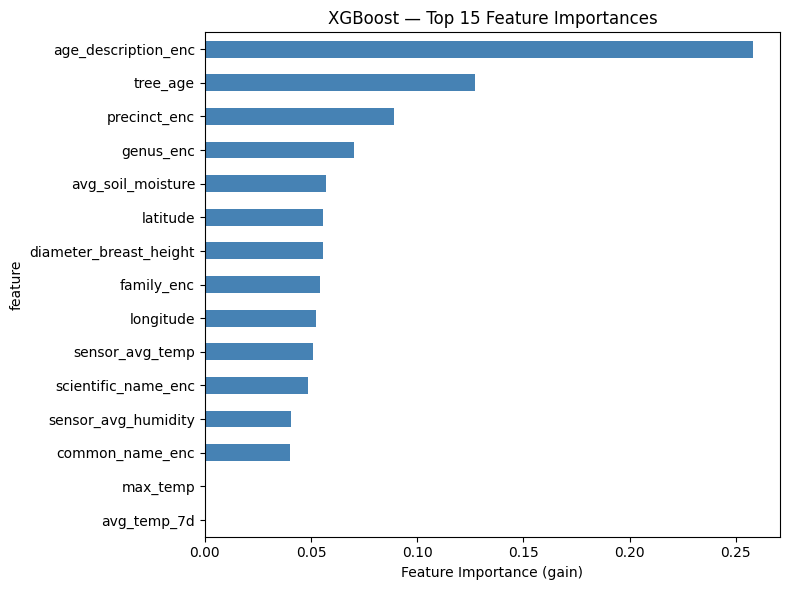

In [76]:
# ============================================================
# 7e. Feature importances
# ============================================================

importances = pd.DataFrame({
    'feature': ALL_FEATURES,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 15 features by importance:")
print(importances.head(15).to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
importances.head(15).plot.barh(x='feature', y='importance', ax=ax, legend=False, color='steelblue')
ax.set_xlabel('Feature Importance (gain)')
ax.set_title('XGBoost — Top 15 Feature Importances')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

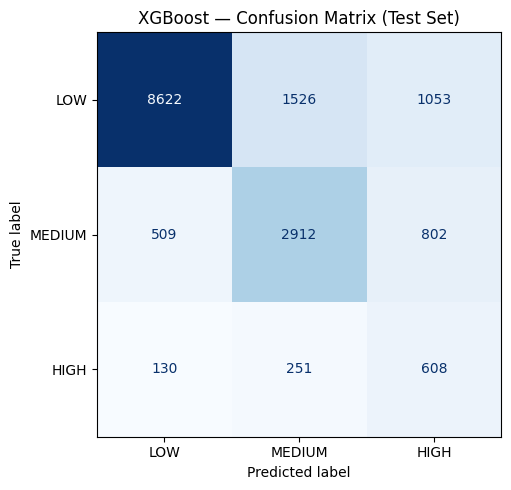

In [77]:
# ============================================================
# 7f. Confusion matrix
# ============================================================

cm = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['LOW', 'MEDIUM', 'HIGH'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('XGBoost — Confusion Matrix (Test Set)')
plt.tight_layout()
plt.show()

=== GLOBAL SHAP SUMMARY (HIGH risk class) ===


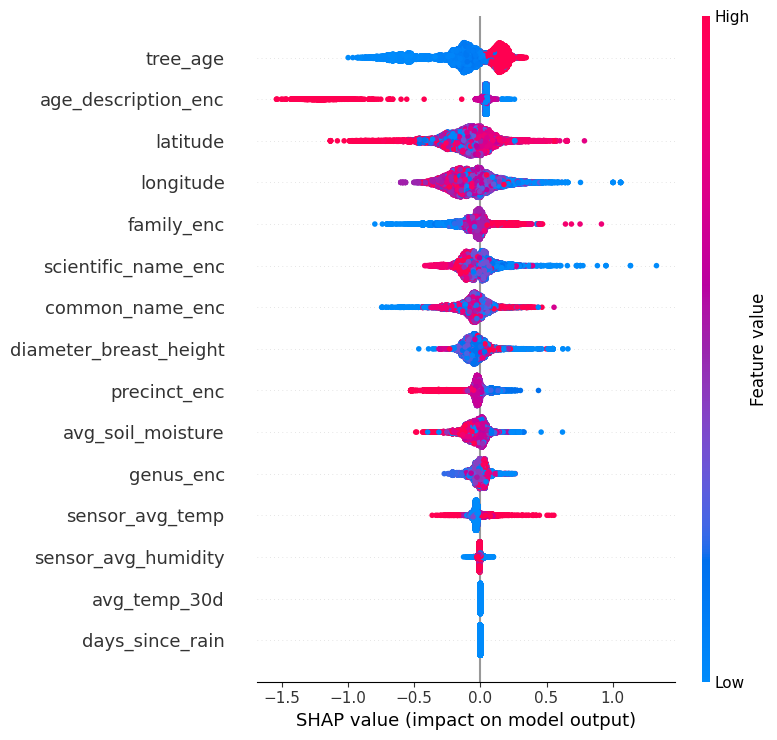

In [78]:
# ============================================================
# 7g. SHAP Values — Per-tree explainability 
# ============================================================
# SHAP (SHapley Additive exPlanations) explains individual predictions
# by attributing each feature's contribution to the final risk score.
# This is critical for real-world deployment — arborists and council
# staff need to understand WHY a tree is flagged not just that it is.
# The top SHAP features per tree are intended to feed into the Layer 3
# RAG/LLM reporting layer, to be implemented in the following trimester.

import shap

# TreeExplainer is optimised for XGBoost — much faster than the generic explainer
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# shap_values is shape (n_samples, n_features, n_classes)
# We focus on class 2 (HIGH risk) — most relevant for arborist action
shap_high = shap_values[:, :, 2]

# --- Global summary plot ---
# Shows which features matter most overall across all trees
print("=== GLOBAL SHAP SUMMARY (HIGH risk class) ===")
shap.summary_plot(
    shap_high,
    X_test,
    feature_names=ALL_FEATURES,
    max_display=15,
    show=True
)

In [79]:
# --- Per-tree SHAP explanation ---
# For each tree, extract its top 3 features driving the HIGH risk score.
# intended to feed into the Layer 3 RAG/LLM reporting layer in the next trimester
# We filter to interpretable features only — latitude/longitude and encoded
# categoricals are not meaningful to include in an arborist report.

shap_df = pd.DataFrame(shap_high, columns=ALL_FEATURES)

# Features that are meaningful to an arborist in a report
INTERPRETABLE_FEATURES = [
    'tree_age', 'diameter_breast_height', 'avg_soil_moisture',
    'sensor_avg_temp', 'sensor_avg_humidity', 'days_since_rain',
    'avg_temp_7d', 'avg_temp_14d', 'avg_temp_30d',
    'heat_degree_days_14d', 'heatwave_flag'
]

def get_top_shap_drivers(shap_row, n=3):
    """Return top n interpretable features positively driving HIGH risk."""
    interpretable = shap_row[INTERPRETABLE_FEATURES]
    positive_only = interpretable[interpretable > 0]
    if len(positive_only) == 0:
        return interpretable.abs().nlargest(n).index.tolist()  # fallback
    return positive_only.nlargest(n).index.tolist()

high_risk_indices = np.where(y_pred_xgb == 2)[0]
print(f"Trees predicted HIGH risk in test set: {len(high_risk_indices)}")
print("\nTop 3 SHAP drivers for 5 example HIGH-risk trees:\n")

for i in high_risk_indices[:5]:
    drivers = get_top_shap_drivers(shap_df.iloc[i])
    values = [f"{d}: {shap_df.iloc[i][d]:+.3f}" for d in drivers]
    print(f"  Tree index {i}: {' | '.join(values)}")

Trees predicted HIGH risk in test set: 2463

Top 3 SHAP drivers for 5 example HIGH-risk trees:

  Tree index 2: tree_age: +0.170
  Tree index 3: diameter_breast_height: +0.545 | tree_age: +0.236 | avg_soil_moisture: +0.071
  Tree index 11: avg_soil_moisture: +0.001
  Tree index 17: diameter_breast_height: +0.008 | avg_soil_moisture: +0.004
  Tree index 22: avg_soil_moisture: +0.038


## Summary
Layer 1 (data pipeline) and Layer 2 (ML risk scoring + SHAP explainability) are complete. Layer 3 (RAG/LLM arborist report generation) will be implemented in the following trimester.